# Unit 4- 类别数据的比较和检验
(updated on 5/05/2026)

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

## Demo 1: 单个比例的置信区间
#### 方法1. Simple Asymptotic : <br>
* 即 $CI=\hat{p}\pm Z_{\alpha/2}\cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$
* 在满足如下条件的时候可以适用： $n<5\%N$比较大，$np>10, n(1-p)>10$, 并且$p$不是非常接近0，或1
* Python 函数statsmodels.stats.proportion.proportion_confint

In [2]:
# Example:
from statsmodels.stats.proportion import proportion_confint
m,n,alpha=14,50,0.05
print(proportion_confint(m,n,alpha,method="normal")) # simple asymptotic 

m,n,alpha=46,100,0.05
print(proportion_confint(m,n,alpha,method="normal")) # simple asymptotic 


(0.15554614523833055, 0.4044538547616695)
(0.36231589837335754, 0.5576841016266425)


In [3]:
?proportion_confint

Signature: proportion_confint(count, nobs, alpha: float = 0.05, method='normal')
Docstring:
Confidence interval for a binomial proportion

Parameters
----------
count : {int or float, array_like}
    number of successes, can be pandas Series or DataFrame. Arrays
    must contain integer values if method is "binom_test".
nobs : {int or float, array_like}
    total number of trials.  Arrays must contain integer values if method
    is "binom_test".
alpha : float
    Significance level, default 0.05. Must be in (0, 1)
method : {"normal", "agresti_coull", "beta", "wilson", "binom_test"}
    default: "normal"
    method to use for confidence interval. Supported methods:

     - `normal` : asymptotic normal approximation
     - `agresti_coull` : Agresti-Coull interval
     - `beta` : Clopper-Pearson interval based on Beta distribution
     - `wilson` : Wilson Score interval
     - `jeffreys` : Jeffreys Bayesian Interval
     - `binom_test` : Numerical inversion of binom_test

Returns
-------

#### 方法1A. Simple Asymptotic  with continuity correction: <br>
即 $CI=\hat{p}\pm (Z_{\alpha/2}\cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}+\frac{1}{2n})$

In [4]:
def proportion_ci_asym_cc(m,n,alpha):
    p=m/n
    z_alpha005=stats.norm.isf(q=alpha/2,loc=0,scale=1)
    sigmap=np.sqrt(p*(1-p)/n)
    return p-z_alpha005*sigmap-1/(2*n),p+z_alpha005*sigmap+1/(2*n)

In [5]:
print(proportion_ci_asym_cc(15,25,alpha))

(np.float64(0.38796353294578756), np.float64(0.8120364670542124))


#### 方法2. Wilson Score : <br>

$w^-=\frac{(2n\hat{p}+z_{1-\alpha/2}^2)-z_{1-\alpha/2} \sqrt{z^2_{1-\alpha/2}+4\hat{p}(n(1-\hat{p}))}}{2(n+z_{1-\alpha/2}^2)}$ 
<br>
$w^+=\frac{(2n\hat{p}+z_{1-\alpha/2}^2)-z_{1-\alpha/2} \sqrt{z^2_{1-\alpha/2}+4\hat{p}(n(1-\hat{p}))}}{2(n+z_{1-\alpha/2}^2)}$


In [6]:
# Example:
m,n,alpha=20,100,0.05
from statsmodels.stats.proportion import proportion_confint
print(proportion_confint(m,n,alpha,method="wilson"))

(0.1333669333310325, 0.2888291655931589)


#### 方法2A. Wilson Score with continuity correction : <br>

$w^-=max \left \{ 0, \frac{(2n\hat{p}+z_{1-\alpha/2}^2-1)-z_{1-\alpha/2} \sqrt{z^2_{1-\alpha/2}-(2+\frac{1}{n})
+4\hat{p}(n(1-\hat{p})+1)}}{2(n+z_{1-\alpha/2}^2)} \right \}$ 
<br>
$w^+=min \left \{ 1, \frac{(2n\hat{p}+z_{1-\alpha/2}^2+1)+z_{1-\alpha/2} \sqrt{z^2_{1-\alpha/2}+(2-\frac{1}{n})
+4\hat{p}(n(1-\hat{p})-1)}}{2(n+z_{1-\alpha/2}^2)} \right \}$


In [7]:
import scipy.stats as stats
import numpy as np
def proportion_ci_wilson_cc(m,n,alpha):
    za=stats.norm.isf(q=alpha/2,loc=0,scale=1)
    p=m/n
    dn=2*(n+za**2)
    nl=(2*n*p+za**2-1)-za*np.sqrt(za**2-(2+1/n)+4*p*(n*(1-p)+1))
    nu=(2*n*p+za**2+1)+za*np.sqrt(za**2+(2-1/n)+4*p*(n*(1-p)-1))
    wl=max(0,nl/dn)
    wu=min(1,nu/dn)
    return wl,wu

In [8]:
#Example:
m,n,alpha=2,100,0.05
print(proportion_ci_wilson_cc(m,n,alpha))

(np.float64(0.0034717126551822293), np.float64(0.07736398830050407))


###### 还有很多种方法，请参考本讲阅读材料，以及 函数 ？proportion_confint

## Demo-2: 两个比例差异的置信区间

##### 方法：有很多方法（参考本讲阅读材料的7种方法），这里提供Pearson Chi-square 方法， 以及对应的Yate's Chi-square with continuity correction

In [9]:
from statsmodels.stats.proportion import confint_proportions_2indep
ci = confint_proportions_2indep(76, 100, 30, 50, method='wald')
print(f"95%信度比例差异区间：{ci}")

95%信度比例差异区间：(np.float64(0.0004825300216998729), np.float64(0.3195174699783002))


In [ ]:
from statsmodels.stats.proportion import confint_proportions_2indep

# 小样本 + 极端比例
ci1 = confint_proportions_2indep(30, 50, 20, 40, method='score', correction=False)
ci2 = confint_proportions_2indep(30, 50, 20, 40, method='score', correction=True)

print(f"未校正的置信区间: {ci1}")
print(f"连续性校正后的置信区间: {ci2}")


未校正的置信区间: (-0.10529298083811345, 0.2984884832725754)
连续性校正后的置信区间: (-0.1064204241203329, 0.29953075520111677)


In [11]:
?confint_proportions_2indep

Signature:
confint_proportions_2indep(
    count1,
    nobs1,
    count2,
    nobs2,
    method=None,
    compare='diff',
    alpha=0.05,
    correction=True,
)
Docstring:
Confidence intervals for comparing two independent proportions.

This assumes that we have two independent binomial samples.

Parameters
----------
count1, nobs1 : float
    Count and sample size for first sample.
count2, nobs2 : float
    Count and sample size for the second sample.
method : str
    Method for computing confidence interval. If method is None, then a
    default method is used. The default might change as more methods are
    added.

    diff:
     - 'wald',
     - 'agresti-caffo'
     - 'newcomb' (default)
     - 'score'

    ratio:
     - 'log'
     - 'log-adjusted' (default)
     - 'score'

    odds-ratio:
     - 'logit'
     - 'logit-adjusted' (default)
     - 'score'

compare : string in ['diff', 'ratio' 'odds-ratio']
    If compare is diff, then the confidence interval is for diff = p1 - p2.
  

## Demo-3:  单个样本的z-test

例如：随机采样100人， 甲流阳性45人， 那么甲流的流行率是否小于50%？

In [12]:
from statsmodels.stats.proportion import proportions_ztest

In [13]:
proportions_ztest(45,100,0.60,alternative="two-sided")

(np.float64(-3.015113445777635), np.float64(0.0025688315270227273))

## Demo 4： 两个独立比例的z-test 

例子： 两个城市的确诊比例($p1, p2$)是否有显著差异？<br>

|  |城市1|城市2|
|:----|:----|:----|
|确诊数|64|92|
|检测数|200|200|



In [14]:
### demo of the example in the course video
count = np.array([17, 39])
nobs = np.array([150, 200])
print(proportions_ztest(count, nobs,alternative="two-sided"))

(np.float64(-2.062394778460764), np.float64(0.039170166029983924))


## Demo 5： 卡方检验RC table

In [3]:
# 如果手工计算Chi2, 计算p值用下面的函数
stats.chi2.sf(6.25,3,0,1)

np.float64(0.10006083311939494)

In [16]:
?stats.chi2_contingency

Signature:
stats.chi2_contingency(
    observed,
    correction=True,
    lambda_=None,
    *,
    method=None,
)
Docstring:
Chi-square test of independence of variables in a contingency table.

This function computes the chi-square statistic and p-value for the
hypothesis test of independence of the observed frequencies in the
contingency table [1]_ `observed`.  The expected frequencies are computed
based on the marginal sums under the assumption of independence; see
`scipy.stats.contingency.expected_freq`.  The number of degrees of
freedom is (expressed using numpy functions and attributes)::

    dof = observed.size - sum(observed.shape) + observed.ndim - 1


Parameters
----------
observed : array_like
    The contingency table. The table contains the observed frequencies
    (i.e. number of occurrences) in each category.  In the two-dimensional
    case, the table is often described as an "R x C table".
correction : bool, optional
    If True, *and* the degrees of freedom is 1, app

### 函数 scipy.stats.chi2_contingency

In [1]:
import pandas as pd
import scipy.stats as stats
data = pd.DataFrame(
    [
        [10,40,5],
        [90,160,95]
    ],
    index=["有症状","无症状"],
    columns=["剂量1","剂量2","剂量3"])


In [2]:
data

,剂量1,剂量2,剂量3
有症状,10,40,5
无症状,90,160,95


In [ ]:
chi2,p,dof,expected=stats.chi2_contingency(data)
# expected 是 Eij的表格值来着
print(chi2,p,dof,expected)

14.229249011857707 0.0008131259780018476 2 [[ 13.75  27.5   13.75]
 [ 86.25 172.5   86.25]]


In [20]:
## 计算Cramer's V
V=np.sqrt(chi2/(400))
print(V)

0.18860838403857944


## Demo-6： 卡方检验- Goodness of Fit

In [21]:
import scipy.stats as stats

In [22]:
# Take the example on ppt
f_obs=[8,10,12,9,11,10]
f_exp=[10,10,10,11,10,9]
stats.chisquare(f_obs,f_exp,ddof=0)

Power_divergenceResult(statistic=np.float64(1.3747474747474748), pvalue=np.float64(0.9270555689565282))

In [23]:
?stats.norm.cdf

Signature: stats.norm.cdf(x, *args, **kwds)
Docstring:
Cumulative distribution function of the given RV.

Parameters
----------
x : array_like
    quantiles
arg1, arg2, arg3,... : array_like
    The shape parameter(s) for the distribution (see docstring of the
    instance object for more information)
loc : array_like, optional
    location parameter (default=0)
scale : array_like, optional
    scale parameter (default=1)

Returns
-------
cdf : ndarray
    Cumulative distribution function evaluated at `x`
File:      e:\anaconda3\envs\med_env\lib\site-packages\scipy\stats\_distn_infrastructure.py
Type:      method

## Extra Demo: Plotting Chi square distribution plot

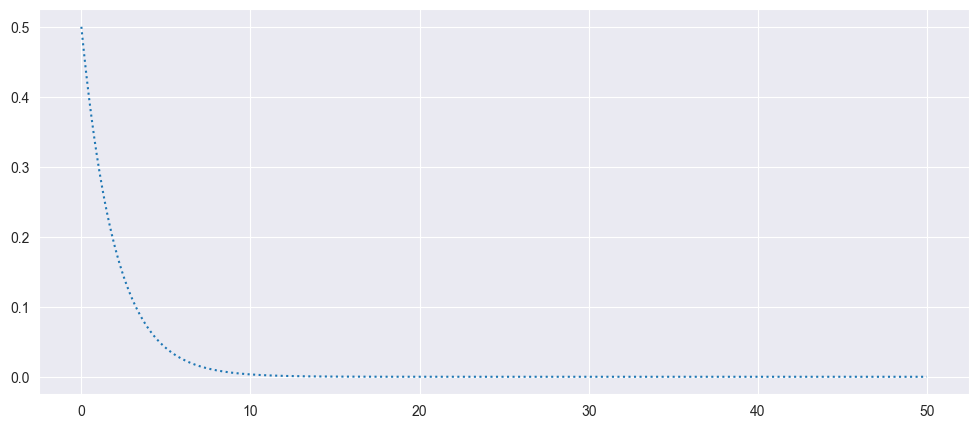

In [24]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.figure(figsize=(12,5))

x=np.linspace(0,50,1000)
y=stats.chi2.pdf(x,df=2,loc=0,scale=1)
plt.plot(x,y,linestyle=":")

In [25]:
?stats.chi2_contingency

Signature:
stats.chi2_contingency(
    observed,
    correction=True,
    lambda_=None,
    *,
    method=None,
)
Docstring:
Chi-square test of independence of variables in a contingency table.

This function computes the chi-square statistic and p-value for the
hypothesis test of independence of the observed frequencies in the
contingency table [1]_ `observed`.  The expected frequencies are computed
based on the marginal sums under the assumption of independence; see
`scipy.stats.contingency.expected_freq`.  The number of degrees of
freedom is (expressed using numpy functions and attributes)::

    dof = observed.size - sum(observed.shape) + observed.ndim - 1


Parameters
----------
observed : array_like
    The contingency table. The table contains the observed frequencies
    (i.e. number of occurrences) in each category.  In the two-dimensional
    case, the table is often described as an "R x C table".
correction : bool, optional
    If True, *and* the degrees of freedom is 1, app

下面的代码有AI生成，提示词： in Python, please plot the chi square distributions for the degree of freedoms from df=1 up to df=5

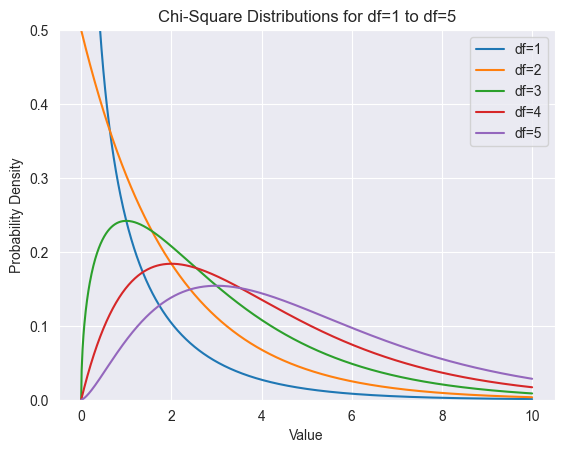

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2

x = np.linspace(0, 10, 1000)

for df in range(1, 6):
    plt.plot(x, chi2.pdf(x, df), label=f'df={df}')

plt.title('Chi-Square Distributions for df=1 to df=5')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()

plt.ylim([0, 0.5])
plt.show()

In [27]:
import pandas as pd
import scipy.stats as stats
data = pd.DataFrame(
    [
        [12,350],
        [8,150]
    ],
    index=["好评","差评"],
    columns=["餐馆A","餐馆B"])


In [28]:
data

,餐馆A,餐馆B
好评,12,350
差评,8,150


In [29]:
chi2,p,dof,expected=stats.chi2_contingency(data,correction=False)
print(chi2,p,dof,expected)

0.9091544863277156 0.3403388579328501 1 [[ 13.92307692 348.07692308]
 [  6.07692308 151.92307692]]


In [30]:
m1,n1,m2,n2,alpha=12,20,350,500,0.05
print(proportion_diff(m1,n1,m2,n2,alpha))
print(proportion_diff_Yate(m1,n1,m2,n2,alpha))

NameError: name 'proportion_diff' is not defined

In [ ]:
count = np.array([12, 350])
nobs = np.array([20, 500])
print(proportions_ztest(count, nobs,alternative="smaller"))

(-0.9534959288469537, 0.17016942896642645)


In [ ]:
?proportions_ztest

In [ ]:
?stats.chisquare

In [ ]:
?stats.chi2_contingency

In [ ]:
-0.9535**2

-0.9091622500000001

### Demo for Week 12
**Week 10 复习思考题：** 进行一项药物实验，将50只感染了某病毒的大鼠进行传统治疗（对照组），以及新药的两种不同剂量治疗（高剂量，低剂量）。 假定该病毒感染不干预治疗的情况下不会自然转阴，三组治疗后的阳性和阴性数目结果如下：

|  | 常规治疗 | 实验组-低剂量 | 实验组-高剂量 |
| --- | --- | --- | --- |
| 阳性 | 10 | 3 | 2 |
| 阴性 | 15 | 10 | 10 |

（1） 如果分别用置信区间和零假设显著性检验推断常规治疗是否有效，请在Python里给出计算并用APA格式汇报和解释结果；

（2）是否可以通过ztest, 或RC表的卡方检验来推断实验组中高剂量和低剂效果是否存在差异？可以的话，请用Python完成，用APA格式汇报，并解释结果；如果不可以，说明为什么？

（3）能否通过卡方检验推断新药与常规治疗存在差异？可以的话，如何进行并在Python里实现，并用APA格式汇报告结果；如果不可以，说明为社么？

（4）上面的问题（3）能否通过ztest进行推断？可以的话请在Python完成，不可以的话，说明为什么？

##### (1) :  如果分别用置信区间和零假设显著性检验推断常规治疗是否有效，请在Python里给出计算并用APA格式汇报和解释结果；

检验是否符合z-分布的置信区间估计： $Np\ge 10$, $N(1-p)\ge 10$

In [ ]:
# 使用 proportion_confint
# APA reporting :  95% CI [LL, UU]

In [ ]:
# proportion_confint

In [ ]:
### demo of the example in the course video
count = np.array([17, 39])
nobs = np.array([150, 200])
# proportions_ztest

In [ ]:
import pandas as pd
import scipy.stats as stats
data = pd.DataFrame(
    [
        [10,3,2],
        [15,10,10]
    ],
    index=["阳性","阴性"],
    columns=["Ctl","LDose","HDose"])


In [ ]:
### demo of the example in the course video
count = np.array([8, 6])
nobs = np.array([142, 142])
print(proportions_ztest(count, nobs,alternative="two-sided"))

(0.5482053452212051, 0.5835509122736893)


In [ ]:
117/142

0.823943661971831

In [ ]:
print(proportion_confint(112,142,0.05,method="normal")) # simple asymptotic 

(0.8697443508667783, 0.9612415646261795)


In [ ]:
m1,n1,m2,n2,alpha=119,142,91,142,0.05
print(proportion_diff(m1,n1,m2,n2,alpha))
print(proportion_diff_Yate(m1,n1,m2,n2,alpha))

(0.09769184571641557, 0.296674351466683)
(0.0906495921952888, 0.3037166049878097)


In [ ]:
130/142-117/142

0.09154929577464788

# Demo for GOF (补充）

1. 我们产生一个正态分布的数据
2. 然后统计不同区间中的观测数
3. 通过观测数的GOF检验来推断是否来自正态分布

In [ ]:
import pandas as pd
import numpy as np
mu,sigma,N=0,5,1000
sigma=5
mu=0
## data for simulation : normal distribution 
data=stats.norm.rvs(mu,sigma,size=N,random_state=120)

# 区间划分， 定义 bins，注意我们使用 np.inf 和 -np.inf 来表示开放区间

intervals=np.linspace(start=-10, stop=10, num=11)

bins=np.append(np.insert(intervals,0,-np.inf),np.inf)

# 使用 pandas 的 cut 函数将数据分到对应的区间段
categories = pd.cut(data, bins)

# 使用 value_counts 函数统计每个区间段的观测数量
counts = categories.value_counts().sort_index()

# 打印结果
print(counts)

(-inf, -10.0]     18
(-10.0, -8.0]     23
(-8.0, -6.0]      55
(-6.0, -4.0]      98
(-4.0, -2.0]     139
(-2.0, 0.0]      146
(0.0, 2.0]       158
(2.0, 4.0]       122
(4.0, 6.0]       117
(6.0, 8.0]        62
(8.0, 10.0]       32
(10.0, inf]       30
dtype: int64


0.0033918327836689943
0.1585932169455342
ShapiroResult(statistic=0.9979069232940674, pvalue=0.2458193600177765)


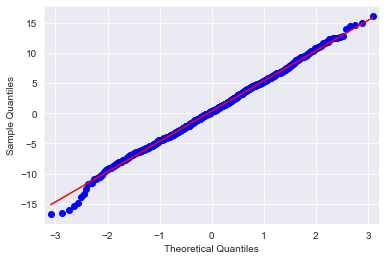

In [ ]:
### 正态性评价的常规方法
print(stats.skew(data))
print(stats.kurtosis(data))
print(stats.shapiro(data))
import statsmodels.api as sm
import matplotlib.pyplot as plt
#create Q-Q plot with 45-degree line added to plot
fig = sm.qqplot(data, stats.norm,line='s')
plt.show()


#### 如果只有counts信息，如何评价

## 方法1： 用传统方法

Key step : from counts 重建数据



In [ ]:
values=np.linspace(start=-11,stop=11,num=12)
values


array([-11.,  -9.,  -7.,  -5.,  -3.,  -1.,   1.,   3.,   5.,   7.,   9.,
        11.])

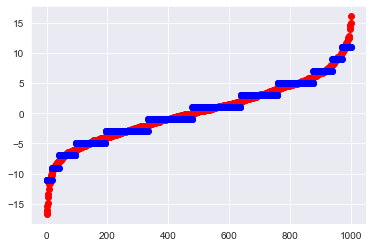

In [ ]:
Rdata=np.repeat(values,counts)
plt.scatter(x=np.arange(N),y=np.sort(data),color="red")
plt.scatter(x=np.arange(N),y=np.sort(Rdata),color="blue")

0.034248744403594246
-0.412673534123452
ShapiroResult(statistic=0.9979069232940674, pvalue=0.2458193600177765)
ShapiroResult(statistic=0.9797925353050232, pvalue=1.4619472299415293e-10)


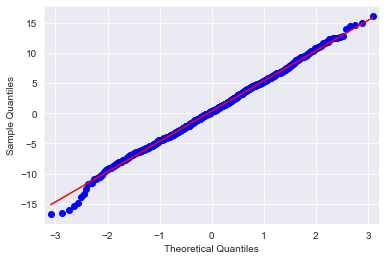

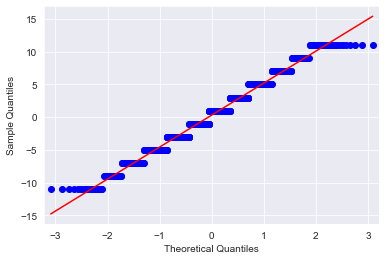

In [ ]:
### 正态性评价的常规方法
print(stats.skew(Rdata))
print(stats.kurtosis(Rdata))
print(stats.shapiro(data))
print(stats.shapiro(Rdata))
#create Q-Q plot with 45-degree line added to plot
fig = sm.qqplot(data, stats.norm,line='s')
plt.show()
fig = sm.qqplot(Rdata, stats.norm,line='s')
plt.show()

## 卡方检验GOF 

In [ ]:
#加入数据来自正态分布
mu=np.mean(Rdata)  # 正态分布的均值（用样本均值代替）
s=np.std(Rdata,ddof=1)  # 正态分布的方差（用样本方差替代）
pi=np.diff(stats.norm.cdf(bins,mu,s)) # 正态分布下各个区间的概率
Ni=pi*len(Rdata)   # 期望(expected 观测数


In [ ]:
# Take the example on ppt
f_obs=counts
f_exp=Ni
stats.chisquare(f_obs,f_exp,ddof=2)

Power_divergenceResult(statistic=8.651480773741365, pvalue=0.47004718030405535)